# Reconstructing the RG → IPC-EN → EN proteome trajectory, without imputing

A joint Bioconductor / scverse analysis of the developing human brain single-cell proteome.

> Wu, T., Jiang, L., Mukhtar, T., Wang, L., Jian, R., Wang, C., Trinh, T., Kriegstein, A. R.,
> Snyder, M. & Li, J. (2026). *Single-cell proteomic landscape of the developing human brain.*
> Nature Biotechnology. [10.1038/s41587-025-02980-7](https://doi.org/10.1038/s41587-025-02980-7)

The analysis runs in two halves that hand data to each other through a single `.h5mu` file:

| | stage | tooling |
|---|---|---|
| **1** | ingest, annotate, normalise, batch-correct | `scpdata` → `QFeatures` → `scp` (*scplainer*) |
| **2** | dimension reduction, embedding, pseudotime | `mudata` → `alphapepttools` → `scanpy` |

`mulink`'s `writeLinkH5MU()` is the bridge. It writes each `QFeatures` set as an `.h5mu`
modality *and* serialises the `AssayLinks` — the peptide→protein provenance graph — into the
global `.varp` group, which plain `MuData::writeH5MU()` has nowhere to put.

## Why this is not the published pipeline

1. The original pipeline had to manually switch between R and Python objects. 


2. Missing proteins were encoded as zero abundance and then passed to `SCTransform()`, which treats them exactly like scRNA-seq dropout counts, i.e. representing them of evidence of absence. At 90% missingness, with a median of 289 proteins identified per
cell, the overwhelming majority of those zeros are stochastic non-sampling.


-- 

This notebook takes the other route. The `QFeatures` object ships the same DIA-NN matrix with
its missing values still as `NA`, and every step below is chosen because it consumes `NA`
directly:

- **scplainer** (`scp::scpModelWorkflow`) fits one linear model per protein on that protein's
  *observed* cells only. A cell where the protein was never identified simply contributes no
  row to the design matrix. Normalisation and batch correction therefore need no imputation.
- **BPCA** (`alphapepttools.tl.bpca`) is a Bayesian latent-variable PCA that marginalises over
  missing entries rather than filling them in.

No value is ever imputed in this notebook.

In [1]:
%load_ext rpy2.ipython

Error importing in API mode: ImportError("dlopen(/Users/lucas-diedrich/mamba/envs/integration/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <2F94BB47-26EE-3EB3-85C5-1EA8A83C71AB> /Users/lucas-diedrich/mamba/envs/integration/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


In [2]:
from pathlib import Path

# Every path below is relative to the repository root, so the notebook runs the
# same whether it is opened from docs/tutorials/ or from the project root.
REPO_ROOT = str(next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists()))
H5MU_PATH = f"{REPO_ROOT}/docs/tutorials/wu2026-trajectory.h5mu"
REPO_ROOT

'/Users/lucas-diedrich/Documents/Projects/scverse/mulink/ms-scverse-bioconductor'

## 1 · Bioconductor — ingest and normalise

In [3]:
%%R
suppressMessages({
    library(QFeatures)
    library(scp)
    library(SingleCellExperiment)
    library(SummarizedExperiment)
    library(MatrixGenerics)
    library(ggplot2)
})

source("../../R/io.R")

Loading required package: Matrix

Attaching package: ‘Matrix’

The following object is masked from ‘package:S4Vectors’:

    expand

Loading required package: rhdf5


### Getting the data

The full object holds 2,313 sets (one per MS run, plus the aggregated ones) and roughly 4.9 GB
in memory. Only the three aggregated sets are needed here, so they are cached separately.

In [4]:
%%R
cache_dir <- path.expand("~/Library/Caches/org.R-project.R/R/scpdata")
agg_rda   <- file.path(cache_dir, "wu2026_aggregated.rda")
full_rda  <- file.path(cache_dir, "wu2026.rda")


# `scpdata::wu2026()` is not callable yet — the dataset's metadata row is still in an open pull
# request, and the accessor is generated from that metadata — so the object is pulled straight
# from the Zenodo record that backs it
# ([10.5281/zenodo.19660264](https://doi.org/10.5281/zenodo.19660264), CC-BY-4.0).
if (!file.exists(agg_rda)) {
    if (!file.exists(full_rda)) {
        dir.create(cache_dir, recursive = TRUE, showWarnings = FALSE)
        download.file("https://zenodo.org/api/records/19660264/files/wu2026.rda/content",
                      full_rda, mode = "wb")
    }
    load(full_rda)
    wu2026 <- wu2026[, , c("peptides", "imported_proteins", "proteins")]
    save(wu2026, file = agg_rda)
}
load(agg_rda)
wu <- wu2026
wu

An instance of class QFeatures (type: scp) with 3 sets:

 [1] peptides: SummarizedExperiment with 17755 rows and 2310 columns 
 [2] imported_proteins: SummarizedExperiment with 4401 rows and 2310 columns 
 [3] proteins: SummarizedExperiment with 5107 rows and 2310 columns 


### The three protein matrices, and where the missingness sits

- **`peptides`** — DIA-NN precursors aggregated to peptides, log-scale.
- **`imported_proteins`** — DIA-NN's own MaxLFQ protein groups, **linear scale**. This is the
  matrix the authors exported, zero-filled, and clustered in Seurat.
- **`proteins`** — `QFeatures`' own peptide→protein aggregation, log-scale.

Note the missing-value fraction of `imported_proteins` against the 90.4% *zeros* in the
authors' CSV: it is the same matrix, with the information about which entries were measured
still intact.

In [5]:
%%R
for (n in names(wu)) {
    m <- assay(wu[[n]])
    cat(sprintf("%-18s %5d x %4d   NA %.1f%%   range %8.2f .. %.3g\n",
                n, nrow(m), ncol(m), 100 * mean(is.na(m)),
                min(m, na.rm = TRUE), max(m, na.rm = TRUE)))
}

peptides           17755 x 2310   NA 93.6%   range     -Inf .. 25.6
imported_proteins   4401 x 2310   NA 90.6%   range    82.59 .. 1.13e+08
proteins            5107 x 2310   NA 97.2%   range     -Inf .. 25.1


### Joining the sample annotation

Cell type calls are not part of the deposited `QFeatures` object; they come from the authors'
Seurat metadata and are joined on `cell_id`. Only the 1,505 cells that survived their
clustering QC carry a label — the remaining 805 are the erythroid and keratin-high clusters
they removed, and they stay `NA` here.

In [6]:
%%R
meta <- read.delim("../../data/wu2026/scp-metadata.tsv")
idx  <- match(rownames(colData(wu)), meta$cell_id)

colData(wu)$celltype <- meta$celltype[idx]
colData(wu)$sample   <- meta$Sample[idx]
colData(wu)$batch    <- factor(colData(wu)$batch)

cat("cells:", nrow(colData(wu)), "| annotated:", sum(!is.na(colData(wu)$celltype)), "\n\n")
print(table(colData(wu)$celltype, useNA = "ifany"))
print(table(colData(wu)$batch, colData(wu)$Region))

cells: 2310 | annotated: 1505 


       EN    IN-CGE    IPC-EN Microglia       OPC       oRG        RG  Vascular 
      171       360       232        54        67       465       129        27 
     <NA> 
      805 
      
        CP  GZ
  S1_1 404 105
  S1_2 296 245
  S2_1  55  23
  S2_2 182 337
  S3_1   0   4
  S3_2   0 659


### Detection depth is confounded with batch

This is the artefact that dominates the dataset. Median proteins identified per cell differs
by more than tenfold across the six acquisition batches, and batch is in turn partly
confounded with anatomical region — `S3_2` is 659 cells, all germinal zone. Any correction has
to remove the depth effect without flattening the CP/GZ axis that the RG→EN trajectory lives
on.

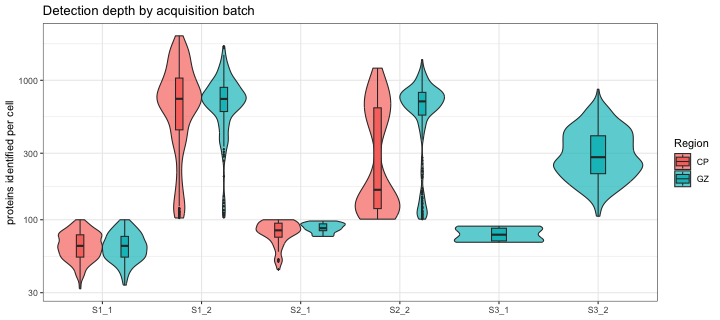

In [7]:
%%R -w 720 -h 320
cd <- as.data.frame(colData(wu))
ggplot(cd, aes(x = batch, y = nFeature_protein, fill = Region)) +
    geom_violin(scale = "width", alpha = .7) +
    geom_boxplot(width = .15, outlier.size = .3, position = position_dodge(.9)) +
    scale_y_log10() +
    labs(y = "proteins identified per cell", x = NULL,
         title = "Detection depth by acquisition batch") +
    theme_bw()

### scplainer: normalisation and batch correction as one linear model

The `imported_proteins` matrix is log2-transformed, and the per-cell **median log2 intensity**
is computed as a normalisation covariate.

The distinction from conventional normalisation matters. Dividing each cell by its median
applies a factor estimated from however few proteins that cell happened to yield — for a cell
with 20 identifications, that factor is close to noise. scplainer instead enters
`MedianIntensity` as a *term in the model*, so it is estimated jointly with everything else
and shrunk accordingly.

In [8]:
%%R
wu <- logTransform(wu, i = "imported_proteins", base = 2, name = "proteins_log")

sce <- as(wu[["proteins_log"]], "SingleCellExperiment")
colData(sce) <- colData(wu)[colnames(sce), ]
sce$MedianIntensity <- colMedians(assay(sce), na.rm = TRUE)

summary(sce$MedianIntensity)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  11.44   13.21   13.78   13.91   14.47   18.52 


One weighted least-squares fit per protein:

$$y_{ij} = \beta_0 + \beta_1\,\text{MedianIntensity}_j + \beta_{\text{batch}(j)} + \varepsilon_{ij}$$

fitted over the cells $j$ in which protein $i$ was **actually observed**. Roughly 4,400 models;
about a minute.

In [9]:
%%R
sce <- scpModelWorkflow(sce, formula = ~ 1 + MedianIntensity + batch, verbose = FALSE)

cat("fitted", nrow(sce), "protein models on", ncol(sce), "cells\n")
print(class(metadata(sce)$model))

fitted 4401 protein models on 2310 cells
[1] "ScpModel"
attr(,"package")
[1] "scp"


### Which proteins can be modelled at all

`n/p` is the number of observations per fitted parameter. A protein seen in only a handful of
cells cannot support a 7-parameter fit, and scplainer drops it rather than extrapolating. This
is the analogue of the feature filter in a conventional pipeline, except the criterion is
*model identifiability* rather than an arbitrary detection cutoff.

median n/p: 14.5 | proteins kept at n/p >= 2: 3189 of 4401 


To change the threshold, use:
scpModelFilterThreshold(object, name) <- threshold


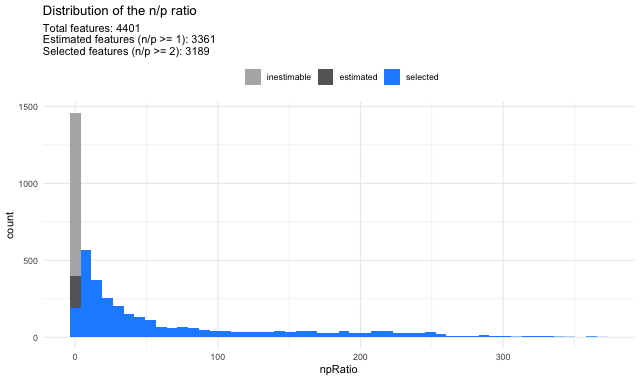

In [10]:
%%R -w 640 -h 380
np <- scpModelFilterNPRatio(sce, filtered = FALSE)
cat("median n/p:", round(median(np, na.rm = TRUE), 1),
    "| proteins kept at n/p >= 2:", sum(np >= 2, na.rm = TRUE), "of", length(np), "\n")

scpModelFilterThreshold(sce, "model") <- 2
scpModelFilterPlot(sce, "model")

### How much variance each term explains

A sanity check on the model before its fitted terms are subtracted. `MedianIntensity` and
`batch` between them account for a substantial share of the variance of a typical protein —
which is precisely why they need removing — but the residual still carries the majority.

In [ ]:
"#A4AFC0"
"#35629b"
"#0e4791"

Saving 2.99 x 4.72 in image


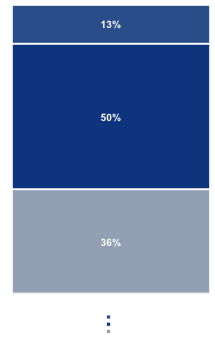

In [247]:
%%R -w 215 -h 340
variance <- scpVarianceAnalysis(sce, "model")

effect_levels  <- c("MedianIntensity", "batch", "Residuals")
effect_colours <- c(Residuals = "#A4AFC0", MedianIntensity = "#35629b", batch = "#0e4791")

variance_df <- do.call(rbind, lapply(names(variance), function(e) {
    d <- as.data.frame(variance[[e]]); d$effect <- e; d
}))

## Sum of squares summed over every protein, then expressed as a share.
pooled <- aggregate(SS ~ effect, variance_df, sum)
pooled$effect <- factor(pooled$effect, levels = effect_levels)
pooled$share  <- 100 * pooled$SS / sum(pooled$SS)

plot <- ggplot(pooled, aes(x = "", y = share, fill = effect)) +
    geom_col(width = .85, colour = "white", linewidth = .8) +
    geom_text(aes(label = sprintf("%.0f%%", share)), position = position_stack(vjust = .5),
              colour = "white", fontface = "bold", size = 3.6) +
    scale_fill_manual(values = effect_colours, breaks = effect_levels) +
    scale_x_discrete(expand = expansion(add = .35)) +
    scale_y_continuous(limits = c(0, 100), breaks = seq(0, 100, 25),
                       expand = expansion(0), labels = function(x) paste0(x, "%")) +
    # labs(title = "Where the variance goes", subtitle = "pooled over all proteins",
    #      x = NULL, y = NULL, fill = NULL) +
    theme_minimal(base_size = 10) +
    theme(panel.grid.major.x   = element_blank(),
          panel.grid.minor     = element_blank(),
          panel.grid.major.y   = element_line(colour = "grey92", linewidth = .3),
          axis.ticks           = element_blank(),
          axis.text.y          = element_text(colour = "grey45"),
          plot.title           = element_text(size = 11, face = "bold", colour = "grey15"),
          plot.subtitle        = element_text(size = 8, colour = "grey45"),
          plot.title.position  = "plot",
          legend.position      = "bottom",
          legend.direction     = "vertical",
          legend.justification = "center",
          legend.key.size      = unit(.5, "lines"),
          legend.text          = element_text(size = 8.5, colour = "grey30"),
          legend.margin        = margin(t = -2),
          text=element_text(family="Aptos"),
          )

ggsave("explained_variance.svg", plot)
plot

### Subtracting the technical terms

`scpRemoveBatchEffect()` returns `intercept + residuals`: the fitted `MedianIntensity` and
`batch` contributions are removed, the intercept is kept so proteins stay on an interpretable
log2 scale. Missing entries are still missing — the correction never invents a value.

In [12]:
%%R
corrected <- scpRemoveBatchEffect(sce, effects = c("MedianIntensity", "batch"),
                                  intercept = TRUE, name = "model")
m <- assay(corrected)
cat(sprintf("corrected: %d x %d | NA %.1f%% | range %.2f .. %.2f\n",
            nrow(m), ncol(m), 100 * mean(is.na(m)),
            min(m, na.rm = TRUE), max(m, na.rm = TRUE)))

corrected: 3189 x 2310 | NA 87.0% | range -16.56 .. 10.45


### Handing over to Python

The corrected matrix goes back into the `QFeatures` object as a new set. `addAssayLinkOneToOne()`
cannot be used — the `n/p` filter dropped rows, so the two sets no longer have matching
dimensions — so the parent/child relation is declared explicitly through a `rowData` key.

`writeLinkH5MU()` then writes the four sets as `.h5mu` modalities and the `AssayLinks` as a
sparse adjacency matrix under `.varp["feature_mapping"]`. This cell takes a few minutes; the
protein matrices are dense with `NaN`.

In [13]:
%%R
rowData(wu[["imported_proteins"]])$.protein <- rownames(wu[["imported_proteins"]])
rd <- rowData(corrected)
rd$.protein <- rownames(corrected)

wu <- addAssay(wu, SummarizedExperiment(assays = list(assay(corrected)), rowData = rd),
               name = "proteins_norm")
wu <- addAssayLink(wu, from = "imported_proteins", to = "proteins_norm",
                   varFrom = ".protein", varTo = ".protein")
print(wu@assayLinks[["proteins_norm"]])

writeLinkH5MU(wu[, , c("peptides", "imported_proteins", "proteins", "proteins_norm")],
              "wu2026-trajectory.h5mu", overwrite = TRUE)

AssayLink for assay <proteins_norm>
[from:imported_proteins|fcol:.protein|hits:3189]


harmonizing input:
  removing 2310 sampleMap rows not in names(experiments)
In addition: Warning message:
In writeLinkH5MU(wu[, , c("peptides", "imported_proteins", "proteins",  :
  Cast NA-bearing integer/logical column(s) 'peptides/rowData$Translated.Quality', 'imported_proteins/rowData$First.Protein.Description', 'proteins/rowData$Translated.Quality', 'proteins_norm/rowData$First.Protein.Description' to double, which MuData encodes in a form Python can read. See cast_nullable_columns().


## 2 · scverse — embedding the corrected proteome

In [ ]:
import logging

import alphapepttools as apt
import matplotlib.pyplot as plt
import mudata as md
import mulink  # noqa: F401  -- registers the .link accessor on MuData
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.stats import median_abs_deviation, spearmanr
from sklearn.metrics import adjusted_rand_score, silhouette_score

from scipy.interpolate import make_smoothing_spline
from matplotlib.colors import to_rgb
from scipy.stats import pearsonr
from alphapepttools.pl.colors import _lighten_color


sc.settings.verbosity = 1
logging.getLogger("alphapepttools.tl.embeddings").setLevel(logging.ERROR)

LINEAGE = ["RG", "IPC-EN", "EN"]

In [15]:
mdata = md.read_h5mu("./wu2026-trajectory.h5mu")

# Character NA crosses the R/HDF5 boundary as an empty string, not as NaN.
mdata.obs["celltype"] = mdata.obs["celltype"].replace("", np.nan).astype("category")
mdata

/Users/lucas-diedrich/mamba/envs/integration/lib/python3.13/site-packages/mudata/_core/io.py:495: OldFormatWarning: Element '/mod/proteins/layers' was written without encoding metadata.
  return func(elem)
/Users/lucas-diedrich/mamba/envs/integration/lib/python3.13/site-packages/mudata/_core/io.py:432: OldFormatWarning: Element '/obsm' was written without encoding metadata.
  d[k] = read_elem(f[k])
/Users/lucas-diedrich/mamba/envs/integration/lib/python3.13/site-packages/mudata/_core/io.py:432: OldFormatWarning: Element '/obsm/imported_proteins' was written without encoding metadata.
  d[k] = read_elem(f[k])
/Users/lucas-diedrich/mamba/envs/integration/lib/python3.13/site-packages/mudata/_core/io.py:432: OldFormatWarning: Element '/obsm/peptides' was written without encoding metadata.
  d[k] = read_elem(f[k])
/Users/lucas-diedrich/mamba/envs/integration/lib/python3.13/site-packages/mudata/_core/io.py:432: OldFormatWarning: Element '/obsm/proteins' was written without encoding metadata.

MuData object with n_obs × n_vars = 2310 × 30452
  obs:	'X', 'orig.ident', 'nCount_protein', 'nFeature_protein', 'ID', 'Sample', 'Region', 'dataset', 'batch', 'celltype', 'sample'
  uns:	'._type'
  varp:	'feature_mapping'
  4 modalities
    imported_proteins:	2310 × 4401
      var:	'Protein.Group', 'Protein.Ids', 'Protein.Names', 'Genes', 'First.Protein.Description', '.protein', 'mulink_feature_id'
      layers:	None
    peptides:	2310 × 17755
      var:	'Platform', 'Protein.Ids', 'Modified.Sequence', 'Stripped.Sequence', 'Proteotypic', 'Translated.Quality', 'IM', 'iIM', 'Predicted.IM', 'Predicted.iIM', 'mulink_feature_id'
      layers:	None
    proteins:	2310 × 5107
      var:	'Platform', 'Protein.Ids', 'Proteotypic', 'Translated.Quality', 'IM', 'iIM', 'Predicted.IM', 'Predicted.iIM', '.n', 'mulink_feature_id'
      layers:	'aggcounts', None
    proteins_norm:	2310 × 3189
      var:	'Protein.Group', 'Protein.Ids', 'Protein.Names', 'Genes', 'First.Protein.Description', '.protein', 'mul

### The feature graph survived the round trip

`.varp["feature_mapping"]` is a DAG over the *global* feature index, so a protein can be traced
back to the peptides it was quantified from — across modalities, which a plain `MuData` object
has no way to express.

Text(0.0, 1.0, 'Peptide → protein provenance')

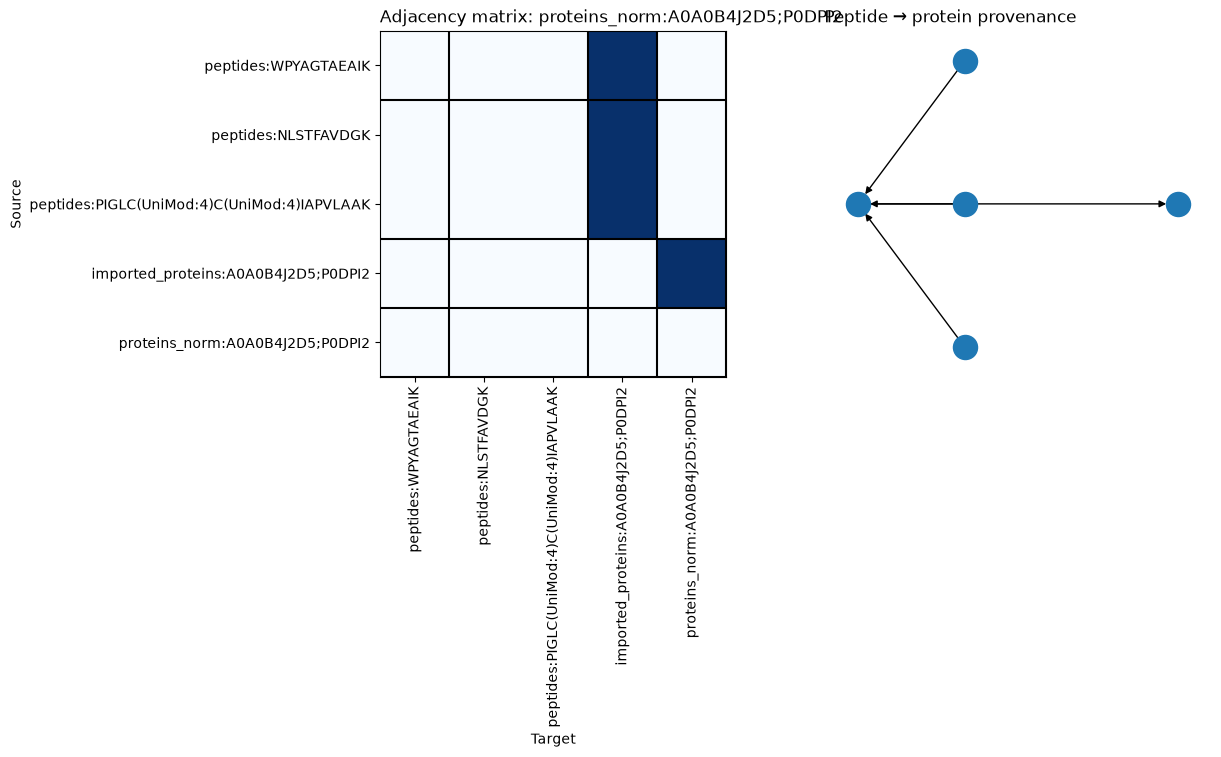

In [16]:
protein = mdata.mod["proteins_norm"].var_names[0]
subset = mdata.link.query.ancestors(protein).copy()

fig, axs = plt.subplots(1, 2, figsize=(11, 4.5))
subset.link.pl.adjacency_matrix(cmap="Blues", label=True, ax=axs[0])
axs[0].set_title(f"Adjacency matrix: {protein}", loc="left")
subset.link.pl.graph(ax=axs[1], with_labels=False)
axs[1].set_title("Peptide → protein provenance", loc="left")

### Quality control

Two per-cell metrics: how many proteins were identified, and the median intensity of those
that were. Outliers are flagged with a median-absolute-deviation rule on the **log** scale —
the raw count distribution is far too skewed (4 to 1,338 proteins per cell) for a MAD rule to
be meaningful untransformed.

In [17]:
def mad_outlier(values, n_mad=3.0, direction="both"):
    """Boolean mask of values further than ``n_mad`` MADs from the median.

    References
    ----------
    Heumos, L. et al. (2023). Best practices for single-cell analysis across
    modalities. Nat Rev Genet 24, 550-572. https://doi.org/10.1038/s41576-023-00586-w
    """
    values = np.asarray(values, dtype=float)
    median = np.nanmedian(values)
    mad = median_abs_deviation(values, nan_policy="omit")
    if mad == 0:
        return ~np.isfinite(values)

    deviation = {
        "both": np.abs(values - median),
        "up": values - median,
        "down": median - values,
    }[direction]
    return (~np.isfinite(values)) | (deviation > n_mad * mad)

/var/folders/py/838_q5nd6594y27wbrpkhl3h0000gn/T/ipykernel_84750/3021619849.py:13: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


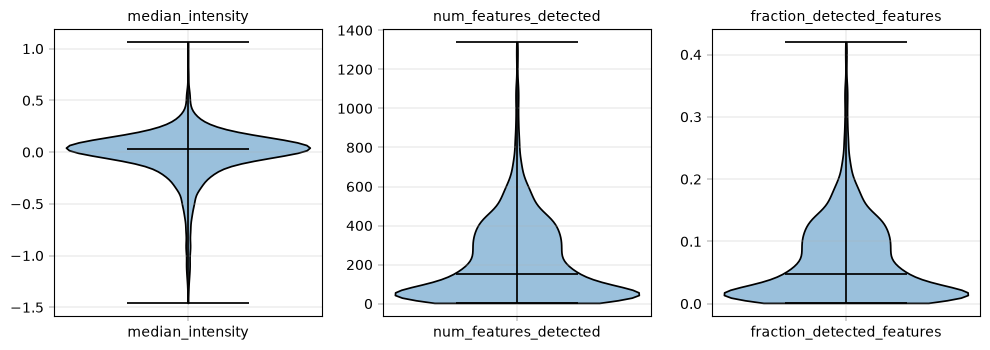

In [18]:
adata = mdata.mod["proteins_norm"].copy()
adata.obs = adata.obs.join(mdata.obs)

apt.metrics.calculate_qc_metrics(adata, layer=None)
adata.obs["median_intensity"] = np.nanmedian(np.asarray(adata.X), axis=1)
adata.obs["log_features_detected"] = np.log1p(adata.obs["num_features_detected"])

fig, axm = apt.pl.create_figure(1, 3, figsize=(10, 3.6))
for feature in ["median_intensity", "num_features_detected", "fraction_detected_features"]:
    ax = axm.next()
    apt.pl.violinplot(ax=ax, data=adata, direct_columns=[feature])
    apt.pl.label_axes(ax, title=feature)
plt.tight_layout()

In [19]:
adata.obs["outlier"] = mad_outlier(adata.obs["log_features_detected"], n_mad=3, direction="down") | mad_outlier(
    adata.obs["median_intensity"], n_mad=3, direction="both"
)

# The 805 unannotated cells are the erythroid and keratin-high clusters the authors
# removed; without a label they cannot serve the cell-type-level analysis below.
keep = (~adata.obs["outlier"]) & adata.obs["celltype"].notna()
print(
    f"{int(adata.obs['outlier'].sum())} QC outliers, "
    f"{int(adata.obs['celltype'].isna().sum())} unannotated -> keeping {int(keep.sum())} of {adata.n_obs}"
)

adata = adata[keep].copy()
adata.obs["celltype"] = adata.obs["celltype"].cat.remove_unused_categories()
apt.metrics.calculate_qc_metrics(adata, layer=None)
adata

317 QC outliers, 805 unannotated -> keeping 1409 of 2310


AnnData object with n_obs × n_vars = 1409 × 3189
    obs: 'X', 'orig.ident', 'nCount_protein', 'nFeature_protein', 'ID', 'Sample', 'Region', 'dataset', 'batch', 'celltype', 'sample', 'total_sample_intensity', 'num_features_detected', 'fraction_detected_features', 'median_intensity', 'log_features_detected', 'outlier'
    var: 'Protein.Group', 'Protein.Ids', 'Protein.Names', 'Genes', 'First.Protein.Description', '.protein', 'mulink_feature_id', 'total_feature_intensity', 'num_samples_detected', 'fraction_detected_samples'
    layers: None (.X)

### Bayesian PCA, and what missingness costs you

`apt.tl.bpca` implements Bishop's Bayesian PCA (Oba et al. 2003). Its latent variables are inferred by marginalising over the unobserved
entries, so it consumes the `NaN` matrix directly.

In [20]:
adata = adata[adata.obs["celltype"].isin(["EN", "IN-CGE", "IPC-EN", "Microglia", "OPC", "RG", "oRG"])].copy()

In [21]:
adata.var["pca_mask"] = adata.var["fraction_detected_samples"] > 0.4
apt.tl.bpca(adata, meta_data_mask_column_name="pca_mask", n_comps=100, embeddings_name="X_bpca")

n_components = int((adata.obsm["X_bpca"].std(axis=0) > 1e-8).sum())
adata.obsm["X_bpca"] = adata.obsm["X_bpca"][:, :n_components]
print(
    f"core proteome: {int(adata.var['pca_mask'].sum())} proteins -> {n_components} components "
    f"({adata.uns['X_bpca']['variance_ratio'].sum():.1%} of variance)"
)

core proteome: 216 proteins -> 11 components (57.3% of variance)


... storing 'orig.ident' as categorical
... storing 'Sample' as categorical
... storing 'Region' as categorical
... storing 'dataset' as categorical
... storing 'sample' as categorical
... storing 'Protein.Group' as categorical
... storing 'Protein.Names' as categorical
... storing 'Genes' as categorical


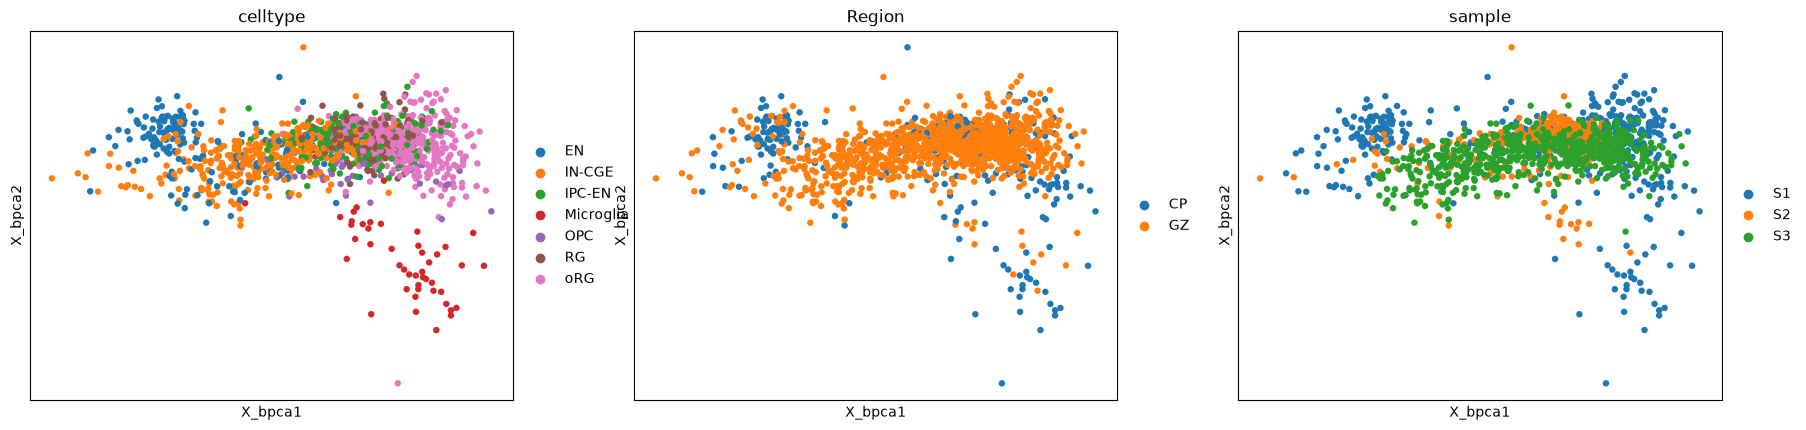

In [22]:
sc.pl.embedding(adata, basis="X_bpca", color=["celltype", "Region", "sample"])

In [23]:
sc.pp.neighbors(adata, n_neighbors=50, use_rep="X_bpca", n_pcs=n_components)
# sc.pp.neighbors(adata, n_neighbors=20, use_rep="X_pca_obs")
sc.tl.leiden(adata, resolution=1.0, key_added="leiden", flavor="igraph", n_iterations=2, random_state=1)

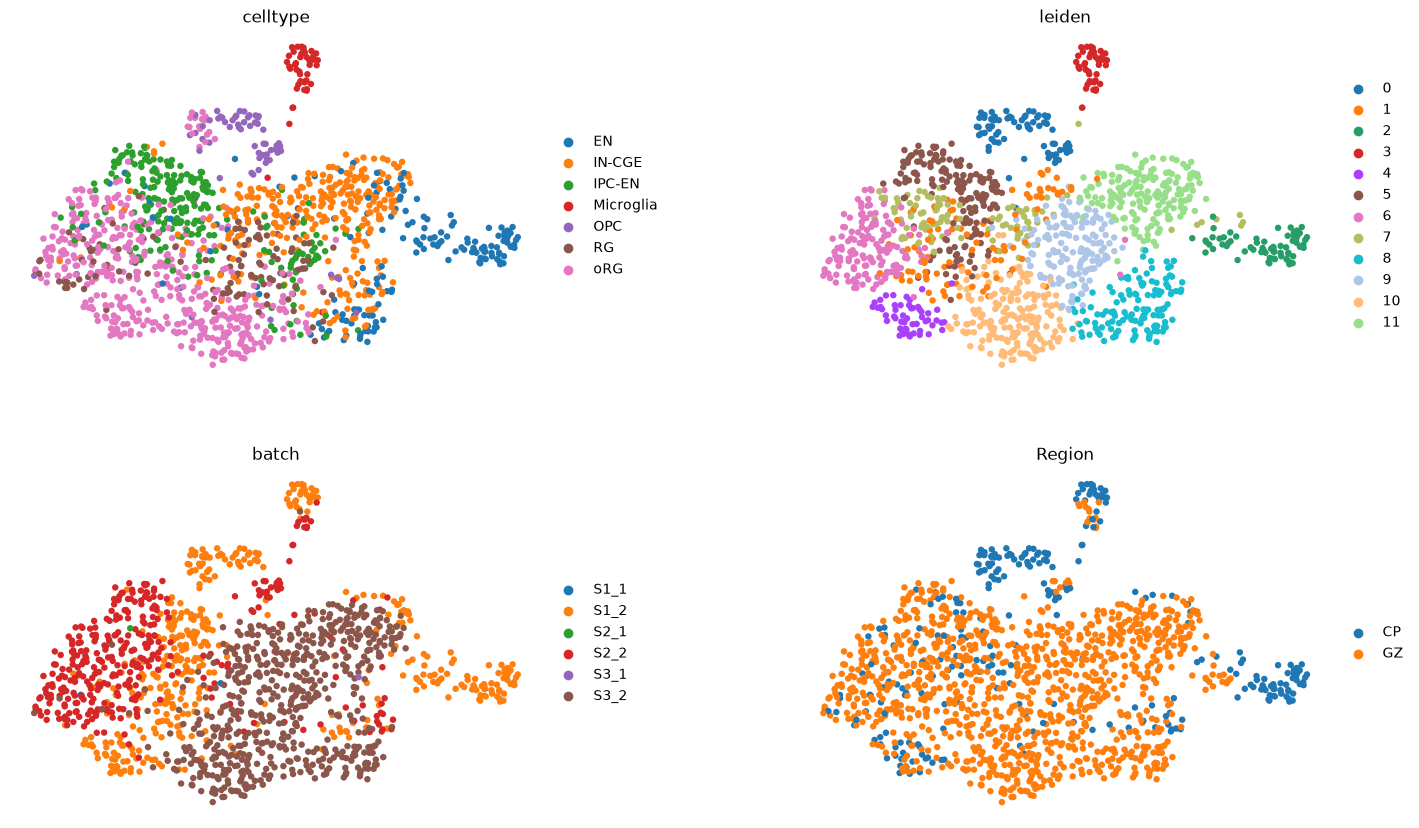

In [24]:
sc.tl.umap(adata, random_state=1)
sc.pl.umap(adata, color=["celltype", "leiden", "batch", "Region"], ncols=2, wspace=0.35, frameon=False)

Cell types are recovered, though not cleanly separated: microglia and vascular cells form a
distinct island, excitatory neurons occupy their own territory, and oRG dominates a third
region — while `batch` and `Region` are well mixed, which is the correction doing its job. The
overlap between the neuronal and progenitor populations is real and expected: this is 200
abundant housekeeping-skewed proteins measured in single cells, not a transcriptome.

In [25]:
crosstab = pd.crosstab(adata.obs["leiden"], adata.obs["celltype"])
display(crosstab)


print(f"silhouette (cell type, BPCA space): {silhouette_score(adata.obsm['X_bpca'], adata.obs['celltype']):.3f}")
print(f"ARI (Leiden vs. cell type):         {adjusted_rand_score(adata.obs['celltype'], adata.obs['leiden']):.3f}")

celltype,EN,IN-CGE,IPC-EN,Microglia,OPC,RG,oRG
leiden,,,,,,,
0,1,0,0,0,52,0,19
1,2,24,21,1,3,11,37
2,69,0,0,0,0,0,0
3,0,0,0,42,0,0,0
4,1,0,0,0,0,1,52
5,3,4,121,0,0,5,28
6,2,4,10,0,3,24,108
7,14,21,17,2,0,8,42
8,44,51,8,1,3,7,11


silhouette (cell type, BPCA space): 0.044
ARI (Leiden vs. cell type):         0.234


## 3 · Diffusion pseudotime along the excitatory neuron lineage

The paper reconstructs radial glia → intermediate progenitor → excitatory neuron at the
protein level. Restricting to those three types and re-deriving the embedding on that subset
matters: the core proteome of 532 lineage cells is not the core proteome of all 1,505, and the
variance that separates neurons from microglia is not the variance that orders a lineage.

In [26]:
lineage = adata[adata.obs["celltype"].isin(LINEAGE)].copy()
lineage.obs["celltype"] = lineage.obs["celltype"].cat.set_categories(LINEAGE)
apt.metrics.calculate_qc_metrics(lineage, layer=None)

lineage.var["pca_mask"] = lineage.var["fraction_detected_samples"] > 0.4
apt.tl.bpca(lineage, meta_data_mask_column_name="pca_mask", n_comps=10, embeddings_name="X_bpca")

n_components = int((lineage.obsm["X_bpca"].std(axis=0) > 1e-8).sum())
lineage.obsm["X_bpca"] = lineage.obsm["X_bpca"][:, :n_components]
print(dict(lineage.obs["celltype"].value_counts()))
print(f"{int(lineage.var['pca_mask'].sum())} proteins -> {n_components} components")

{'IPC-EN': np.int64(230), 'EN': np.int64(166), 'RG': np.int64(121)}
262 proteins -> 3 components


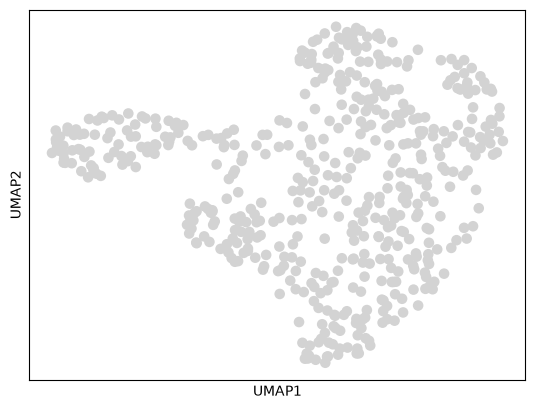

In [27]:
sc.pp.neighbors(lineage, n_neighbors=30, use_rep="X_bpca")
sc.tl.umap(lineage, min_dist=0.5)
sc.pl.umap(lineage)

PAGA recovers the expected topology without being told the ordering: RG–IPC-EN is by far the
strongest connection, IPC-EN–EN is intermediate, and RG–EN — the transition that should *not*
happen directly — is the weakest.

Diffusion pseudotime is then rooted in radial glia. The diffusion map is computed from the kNN
graph rather than from the BPCA coordinates directly, so it is not limited to the three
components ARD retained.

In [28]:
sc.tl.diffmap(lineage, n_comps=15)

# Root at the most extreme RG cell along the first non-trivial diffusion component
# (DC0 is the constant eigenvector and carries no information).
rg_cells = np.flatnonzero(lineage.obs["celltype"] == "RG")
lineage.uns["iroot"] = int(rg_cells[np.argmax(lineage.obsm["X_diffmap"][rg_cells, 1])])

sc.tl.dpt(lineage, n_dcs=10)

In [30]:
apt.tl.bpca(lineage, meta_data_mask_column_name="pca_mask")
sc.pp.neighbors(lineage, n_neighbors=15, use_rep="X_bpca_obs", random_state=1)
sc.tl.umap(lineage, random_state=1)

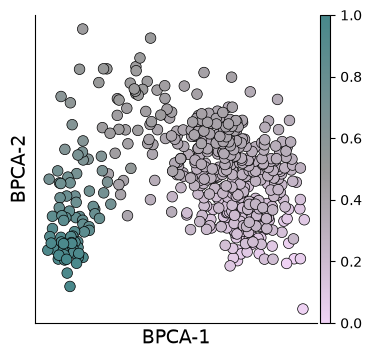

In [45]:
import matplotlib as mpl

cmap = mpl.colors.LinearSegmentedColormap.from_list("custom", ["#f0d3f5", "#999999", "#47888b"])
# norm = mpl.colors.Normalize("custom", ["#f0d3f5", "#f0d3f5", "#999999", "#47888b"])


with mpl.rc_context({"ps.fonttype": 42}):
    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    sc.pl.embedding(
        lineage,
        basis="X_bpca_obs",
        color="dpt_pseudotime",
        ax=ax,
        show=False,
        cmap=cmap,
        edgecolor="k",
        lw=0.5,
        title="",
        groups="celltype",
    )
    ax.spines[["top", "right"]].set_visible(False)

    ax.set_xlabel("BPCA-1", fontsize=14)
    ax.set_ylabel("BPCA-2", fontsize=14)

fig.savefig("./diffusion-time.svg", transparent=True)

{'variance_ratio': array([0.1703763218, 0.092010491 , 0.0674882004, 0.0521922586,
        0.0463316496, 0.0377690449, 0.0263407852, 0.0245449106,
        0.0201937816, 0.0199270294, 0.0161601537, 0.          ,
        0.          , 0.          , 0.          , 0.          ,
        0.          , 0.          , 0.          , 0.          ,
        0.          , 0.          , 0.          , 0.          ,
        0.          , 0.          , 0.          , 0.          ,
        0.          , 0.          , 0.          , 0.          ,
        0.          , 0.          , 0.          , 0.          ,
        0.          , 0.          , 0.          , 0.          ,
        0.          , 0.          , 0.          , 0.          ,
        0.          , 0.          , 0.          , 0.          ,
        0.          , 0.          , 0.          , 0.          ,
        0.          , 0.          , 0.          , 0.          ,
        0.          , 0.          , 0.          , 0.          ,
        0.          , 

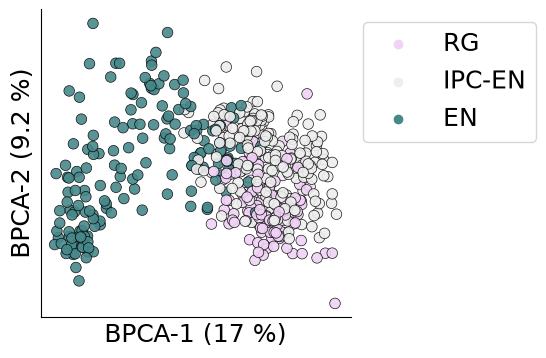

In [212]:
with mpl.rc_context({"ps.fonttype": 42}):
    fig, ax = plt.subplots(1, 1, figsize=(4, 4))

    sc.pl.embedding(
        lineage,
        basis="X_bpca_obs",
        color="celltype",
        ax=ax,
        show=False,
        edgecolor="k",
        lw=0.5,
        title="",
        palette=["#f0d3f5", "#eeeeee", "#47888b"],
        alpha=0.9,
    )
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=18)

    explained_variance = list(adata.uns["X_bpca"]["variance_ratio"])

    ax.set_xlabel(f"BPCA-1 ({explained_variance[0] * 100:.2g} %)", fontsize=18)
    ax.set_ylabel(f"BPCA-2 ({explained_variance[1] * 100:.2g} %)", fontsize=18)

fig.savefig("./bpca-cell-type.svg", transparent=True, bbox_inches="tight")

,median,mean,count
celltype,,,
RG,0.174,0.177,121
IPC-EN,0.305,0.292,230
EN,0.487,0.591,166


Spearman(cell-type order, pseudotime) = 0.754  (p = 6.00e-96)


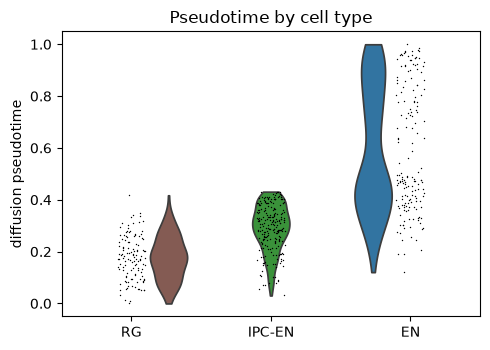

In [33]:
fig, ax = plt.subplots(figsize=(5, 3.6))
sc.pl.violin(lineage, keys="dpt_pseudotime", groupby="celltype", ax=ax, show=False, order=LINEAGE, rotation=0)
ax.set(title="Pseudotime by cell type", xlabel=None, ylabel="diffusion pseudotime")
plt.tight_layout()

summary = lineage.obs.groupby("celltype", observed=True)["dpt_pseudotime"].agg(["median", "mean", "count"])
display(summary.round(3))

rho, pvalue = spearmanr(
    lineage.obs["celltype"].map({c: i for i, c in enumerate(LINEAGE)}), lineage.obs["dpt_pseudotime"]
)
print(f"Spearman(cell-type order, pseudotime) = {rho:.3f}  (p = {pvalue:.2e})")

Pseudotime increases monotonically across RG → IPC-EN → EN, and correlates with the known
ordering at ρ ≈ 0.75. Nothing in the pipeline was given that ordering: the cell type labels
were used only to subset the lineage and to pick a root population.

### Proteins that track the transition

Correlating each protein in the core set against pseudotime gives the protein-level analogue
of the paper's stage-specific modules. Correlations are computed on observed values only —
`scipy`'s `spearmanr` with `nan_policy="omit"` — so a protein missing in a cell contributes
nothing rather than a fabricated zero.

In [34]:
core = lineage[:, lineage.var["pca_mask"].values]
X = np.asarray(core.X)
pseudotime = lineage.obs["dpt_pseudotime"].to_numpy()

records = []
for j, gene in enumerate(core.var["Genes"].astype(str)):
    observed = np.isfinite(X[:, j])
    if observed.sum() < 50:
        continue
    r, p = spearmanr(X[observed, j], pseudotime[observed])
    records.append(
        {"protein": core.var_names[j], "gene": gene, "n_observed": int(observed.sum()), "rho": r, "pvalue": p}
    )

correlations = pd.DataFrame(records).sort_values("rho")
print(f"{len(correlations)} proteins tested")
display(pd.concat([correlations.head(8), correlations.tail(8)]).round(4))

262 proteins tested


,protein,gene,n_observed,rho,pvalue
70,proteins_norm:P19338,NCL,517,-0.6385,0.0
175,proteins_norm:Q02878,RPL6,514,-0.5792,0.0
111,proteins_norm:P46776,RPL27A,511,-0.5688,0.0
37,proteins_norm:P08865,RPSA,512,-0.5477,0.0
95,proteins_norm:P32969,RPL9P9,423,-0.4992,0.0
154,proteins_norm:P62917,RPL8,488,-0.4948,0.0
136,proteins_norm:P61604,HSPE1,515,-0.4862,0.0
19,proteins_norm:P00338,LDHA,516,-0.4836,0.0
195,proteins_norm:Q14194,CRMP1,497,0.7697,0.0
215,proteins_norm:Q16658,FSCN1,507,0.7781,0.0


In [35]:
GENE = "ZBTB18"
lineage.var[lineage.var["Genes"] == GENE]

lineage.obs[GENE] = lineage[:, lineage.var["Genes"] == GENE].X.flatten().tolist()
lineage.obs[GENE] = lineage.obs[GENE]

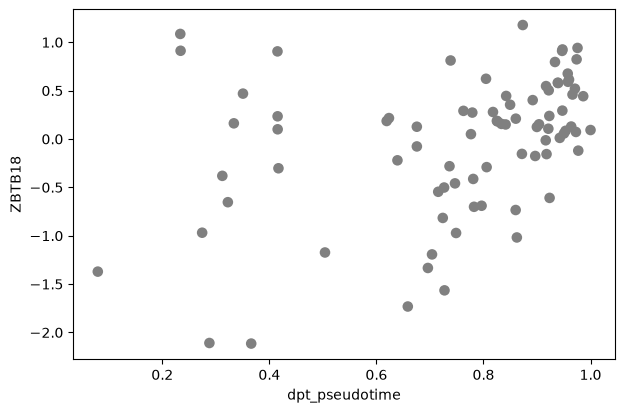

In [36]:
sc.pl.scatter(lineage, x="dpt_pseudotime", y=GENE)

/var/folders/py/838_q5nd6594y27wbrpkhl3h0000gn/T/ipykernel_84750/4288826321.py:9: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


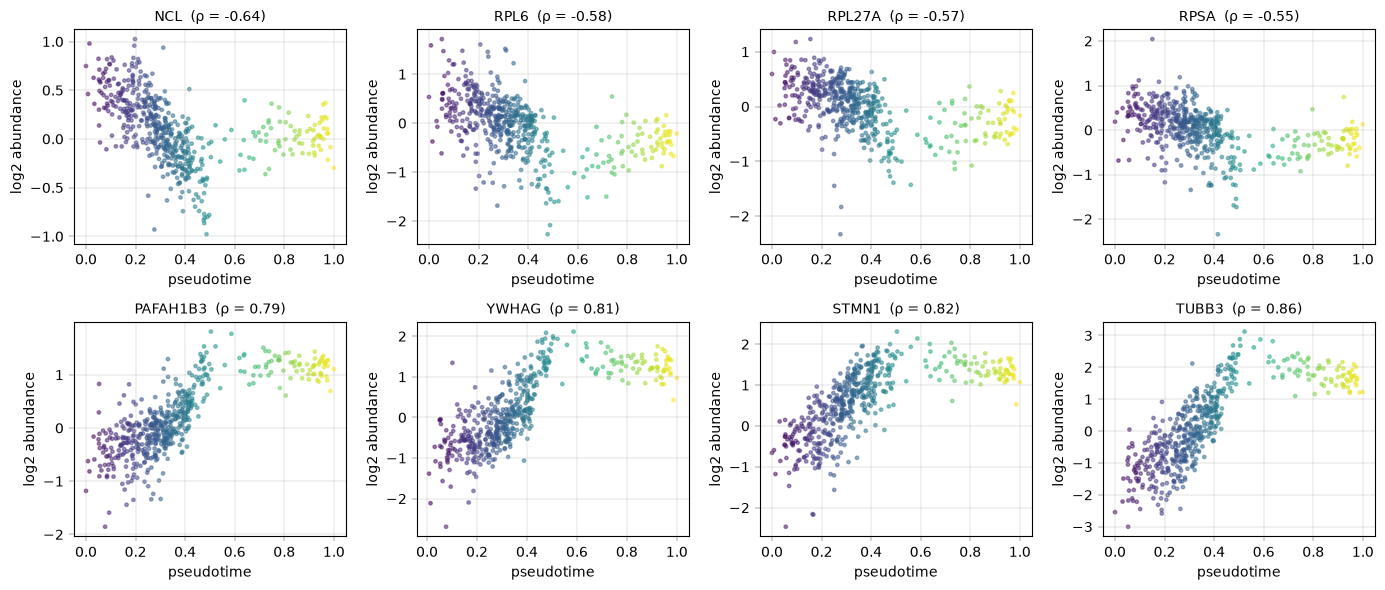

In [37]:
top = pd.concat([correlations.head(4), correlations.tail(4)])
fig, axm = apt.pl.create_figure(2, 4, figsize=(14, 6))
for _, row in top.iterrows():
    ax = axm.next()
    values = X[:, core.var_names.get_loc(row["protein"])]
    observed = np.isfinite(values)
    ax.scatter(pseudotime[observed], values[observed], s=6, alpha=0.5, c=pseudotime[observed], cmap="viridis")
    apt.pl.label_axes(ax, title=f"{row['gene']}  (ρ = {row['rho']:.2f})", xlabel="pseudotime", ylabel="log2 abundance")
plt.tight_layout()

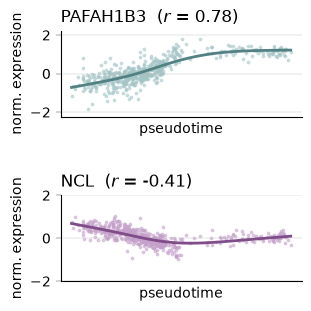

In [185]:
t = np.linspace(0, 1, 100)
pseudotime = lineage.obs["dpt_pseudotime"].values.flatten()

with mpl.rc_context({"ps.fonttype": 42}):
    fig, axm = apt.pl.create_figure(2, 1, figsize=(3, 3), gridspec_kwargs={"hspace": 0.25})
    for gene, color in zip(("PAFAH1B3", "NCL"), ("#528184", "#804c8a"), strict=True):
        values = lineage.X[:, lineage.var["Genes"] == gene].flatten()
        keep = np.isfinite(values.flatten()) & np.isfinite(pseudotime.flatten())

        r_pearson = pearsonr(pseudotime[keep], values[keep]).statistic

        ax = axm.next()

        label = rf"{gene}  ($r$ = {r_pearson:.2f})"
        mappable = ax.scatter(pseudotime, values, s=3, alpha=0.5, color=_lighten_color(to_rgb(color)), label=label)

        apt.pl.label_axes(ax, xlabel="pseudotime", ylabel="norm. expression")
        ax.set_title(label, loc="left")
        ylim = 1.2 * np.nanmax(np.abs(values))
        ax.set_ylim(-ylim, ylim)
        ax.set_yticks([-2, 0, 2], minor=False)
        ax.set_yticks([-2, 0, 2], minor=True)
        ax.grid(visible=False, axis="x")
        ax.spines[["top", "right"]].set_visible(False)
        ax.set_xticks([])

        pt = pseudotime[keep]
        v = values[keep]
        order = np.argsort(pt)

        spl = make_smoothing_spline(pt[order], v[order], lam=0.1)

        ax.plot(t, spl(t), color=color, lw=2)

fig.savefig("./diffusion-time-genes.svg", transparent=True)

In [128]:
np.isnan(pt).sum()

np.int64(0)

In [114]:
pt

NameError: name 'pt' is not defined